# EPMT Data "Cleanup"

Taking 40k rows of EPMT data pulled from the database and written to file on Feb 7th, 2026, and cleaning that up so that it can be more easily used for Machine Learning. Revised version will be written to file as csv, hopefully with data normalization and outliers removed.


In [1]:
%pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pprint
import ast
from datetime import datetime

%matplotlib inline 

# Suggested by Gemini -- "Makes your plots look a bit more modern/clean"
sns.set_theme(style="whitegrid")

# Load some data

In [3]:
import glob
import os

data_path = './data_40000_20260207_083037' 

all_files = glob.glob(os.path.join(data_path, "*.csv"))

df_list = [pd.read_csv(f) for f in all_files]
df = pd.concat(df_list, ignore_index=True)
print(f"Loaded {len(all_files)} files.")
pprint.pprint(all_files)


Loaded 8 files.
['./data_40000_20260207_083037/jk_data_40000_4_20260207_083037.csv',
 './data_40000_20260207_083037/jk_data_40000_5_20260207_083037.csv',
 './data_40000_20260207_083037/jk_data_40000_6_20260207_083037.csv',
 './data_40000_20260207_083037/jk_data_40000_7_20260207_083037.csv',
 './data_40000_20260207_083037/jk_data_40000_1_20260207_083037.csv',
 './data_40000_20260207_083037/jk_data_40000_3_20260207_083037.csv',
 './data_40000_20260207_083037/jk_data_40000_2_20260207_083037.csv',
 './data_40000_20260207_083037/jk_data_40000_8_20260207_083037.csv']


In [4]:
df.columns.tolist()

['read_bytes',
 'write_bytes',
 'time_waiting',
 'cpu_time',
 'duration',
 'start',
 'end',
 'minflt',
 'majflt',
 'tags',
 'annotations',
 'all_proc_tags',
 'exitcode',
 'SLURM_JOB_ACCOUNT',
 'SLURM_NTASKS',
 'SLURM_TASKS_PER_NODE',
 'SLURM_MEM_PER_CPU',
 'SLURM_MEM_PER_NODE',
 'SLURM_SCRIPT_CONTEXT',
 'LOADEDMODULES']

In [5]:
len(df)

40000

# Parse the annotations

In a rush, the data was just written to file, and now we have to parse it. It's basically the EPMT_JOB_TAGS, with some papiex-related tags.

In [6]:
#Just look at one of them for now
type(df.iloc[0]['annotations'])
annotations = ast.literal_eval(df.iloc[0]['annotations'])
epmt_job_tags_str = annotations['EPMT_JOB_TAGS']
epmt_job_tags_str

'exp_component:ocean_rho2;exp_fre_mod:/home/fms/local/opt/fre-commands/bronx-23;exp_name:SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X;exp_time:00390101;exp_platform:gfdl.ncrc5-intel23_2_0;exp_target:repro-openmp;exp_seg_months:12;script_name:SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X_ocean_rho2_00390101'

In [7]:
# Turn all of the annotations from strings to dictionaries to process easier
expanded_annotations = pd.json_normalize(df["annotations"].apply(ast.literal_eval))
expanded_annotations

,EPMT_JOB_TAGS,papiex-error,papiex-error-process-ids
0,exp_component:ocean_rho2;exp_fre_mod:/home/fms...,NaN,NaN
1,exp_component:ocean_z;exp_fre_mod:/home/fms/lo...,NaN,NaN
2,exp_component:ocean;exp_fre_mod:/home/fms/loca...,NaN,NaN
3,exp_component:ocean_scalar;exp_fre_mod:/home/f...,NaN,NaN
4,exp_component:ice;exp_fre_mod:/home/fms/local/...,NaN,NaN
...,...,...,...
39995,exp_component:ocean_monthly_z;exp_fre_mod:/hom...,NaN,NaN
39996,exp_component:ocean_monthly_rho0;exp_fre_mod:/...,NaN,NaN
39997,exp_component:ocean_monthly_rho2;exp_fre_mod:/...,NaN,NaN
39998,exp_component:ocean_annual_z;exp_fre_mod:/home...,NaN,NaN


In [8]:
# Now, expand the EPMT_JOB_TAGS strings into dictionaries
def parse_key_val_str(kv_str: str):
    if not isinstance(kv_str, str) or not kv_str:
        return {}
    return dict(item.split(":") for item in kv_str.split(";"))

expanded_annotations["parsed_EPMT_JOB_TAGS"] = expanded_annotations["EPMT_JOB_TAGS"].apply(parse_key_val_str)

In [9]:
# Turn the dictionaries into columns with values using pd.Series
# Join the parsed EPMT tags to the expanded annotations
parsed_epmt_data = expanded_annotations.join(expanded_annotations["parsed_EPMT_JOB_TAGS"].apply(pd.Series)) 

In [10]:
# Finally, join the tags to the original dataframe
df = df.join(parsed_epmt_data)
df.drop(columns=['parsed_EPMT_JOB_TAGS'])

,read_bytes,write_bytes,time_waiting,cpu_time,duration,start,end,minflt,majflt,tags,...,papiex-error,papiex-error-process-ids,exp_component,exp_fre_mod,exp_name,exp_time,exp_platform,exp_target,exp_seg_months,script_name
0,143108292608,87625113600,1576818392,2.447686e+08,1.351581e+09,2026-01-28 09:15:39.211909,2026-01-28 09:38:10.792654,16121206,89,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,NaN,NaN,ocean_rho2,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
1,530551828480,320059248640,1609037432,8.158229e+08,2.690247e+09,2026-01-28 09:15:39.224952,2026-01-28 10:00:29.471986,67307150,95,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,NaN,NaN,ocean_z,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
2,20732755968,15446900736,1287584605,7.107885e+07,1.103452e+09,2026-01-28 09:15:39.234004,2026-01-28 09:34:02.685979,5572074,1,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,NaN,NaN,ocean,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
3,2519040,9170944,1060678240,1.574165e+07,7.748793e+08,2026-01-28 09:15:39.267702,2026-01-28 09:28:34.147049,1831911,9,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,NaN,NaN,ocean_scalar,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
4,51357884416,39814533120,2412909975,2.985102e+08,1.657239e+09,2026-01-28 09:15:39.495806,2026-01-28 09:43:16.734767,10174529,0,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,NaN,NaN,ice,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,00390101,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,949433233408,1093601648640,8003719425,2.194842e+09,3.618123e+09,2026-02-04 14:22:53.830723,2026-02-04 15:23:11.953871,187455457,814,"{'exp_name': 'abrupt-4xCO2_fire_chem_climo', '...",...,NaN,NaN,ocean_monthly_z,/home/fms/local/opt/fre-commands/test,abrupt-4xCO2_fire_chem_climo,00850101,gfdl.ncrc5-intel25,prod-openmp,12,abrupt-4xCO2_fire_chem_climo_ocean_monthly_z_0...
39996,12288,3895296,618124336,3.584483e+06,4.279246e+07,2026-02-04 14:22:56.814316,2026-02-04 14:23:39.606775,453152,0,"{'exp_name': 'abrupt-4xCO2_fire_chem_climo', '...",...,NaN,NaN,ocean_monthly_rho0,/home/fms/local/opt/fre-commands/test,abrupt-4xCO2_fire_chem_climo,00850101,gfdl.ncrc5-intel25,prod-openmp,12,abrupt-4xCO2_fire_chem_climo_ocean_monthly_rho...
39997,106496,4939776,1506755561,6.771812e+06,5.475408e+07,2026-02-04 14:22:59.839467,2026-02-04 14:23:54.593549,865908,5,"{'exp_name': 'abrupt-4xCO2_fire_chem_climo', '...",...,NaN,NaN,ocean_monthly_rho2,/home/fms/local/opt/fre-commands/test,abrupt-4xCO2_fire_chem_climo,00850101,gfdl.ncrc5-intel25,prod-openmp,12,abrupt-4xCO2_fire_chem_climo_ocean_monthly_rho...
39998,232376201216,379891113984,6402154311,9.620012e+08,1.618102e+09,2026-02-04 14:23:04.040949,2026-02-04 14:50:02.142913,126774627,1437,"{'exp_name': 'abrupt-4xCO2_fire_chem_climo', '...",...,NaN,NaN,ocean_annual_z,/home/fms/local/opt/fre-commands/test,abrupt-4xCO2_fire_chem_climo,00850101,gfdl.ncrc5-intel25,prod-openmp,12,abrupt-4xCO2_fire_chem_climo_ocean_annual_z_00...


In [11]:
df.columns.tolist()

['read_bytes',
 'write_bytes',
 'time_waiting',
 'cpu_time',
 'duration',
 'start',
 'end',
 'minflt',
 'majflt',
 'tags',
 'annotations',
 'all_proc_tags',
 'exitcode',
 'SLURM_JOB_ACCOUNT',
 'SLURM_NTASKS',
 'SLURM_TASKS_PER_NODE',
 'SLURM_MEM_PER_CPU',
 'SLURM_MEM_PER_NODE',
 'SLURM_SCRIPT_CONTEXT',
 'LOADEDMODULES',
 'EPMT_JOB_TAGS',
 'papiex-error',
 'papiex-error-process-ids',
 'parsed_EPMT_JOB_TAGS',
 'exp_component',
 'exp_fre_mod',
 'exp_name',
 'exp_time',
 'exp_platform',
 'exp_target',
 'exp_seg_months',
 'script_name']

# Dropping some obviously useless columns
For example, the exitcodes all seem to have ended successfully, with value 0. That's not very useful, so let's remove them for now then. Same goes for some more columns.

In [12]:
df['exitcode'].value_counts().sort_index()

exitcode
0    40000
Name: count, dtype: int64

In [13]:
df = df.drop(columns=['exitcode'])

In [14]:
df['SLURM_MEM_PER_NODE'].value_counts().sort_index()

SLURM_MEM_PER_NODE
204800.0    5084
Name: count, dtype: int64

In [15]:
df = df.drop(columns=['SLURM_MEM_PER_NODE'])

In [16]:
df['SLURM_MEM_PER_CPU'].value_counts().sort_index()

SLURM_MEM_PER_CPU
16384.0    34113
Name: count, dtype: int64

In [17]:
df = df.drop(columns=['SLURM_MEM_PER_CPU'])

In [18]:
df['SLURM_NTASKS'].value_counts().sort_index()

SLURM_NTASKS
1.0    39933
2.0       17
Name: count, dtype: int64

In [19]:
# It's hard to tell if those 17 values will be useful or cause overtitting
df[df['SLURM_NTASKS'] == 2]['cpu_time'].describe()

count    1.700000e+01
mean     1.618032e+08
std      4.167083e+08
min      2.327040e+06
25%      4.333965e+06
50%      1.464288e+07
75%      2.769425e+07
max      1.536813e+09
Name: cpu_time, dtype: float64

In [20]:
df[df['SLURM_NTASKS'] == 1]['cpu_time'].describe()

count    3.993300e+04
mean     5.577500e+08
std      1.592306e+09
min      8.745270e+05
25%      2.596071e+07
50%      7.293561e+07
75%      3.121522e+08
max      3.527593e+10
Name: cpu_time, dtype: float64

<Axes: xlabel='SLURM_NTASKS', ylabel='cpu_time'>

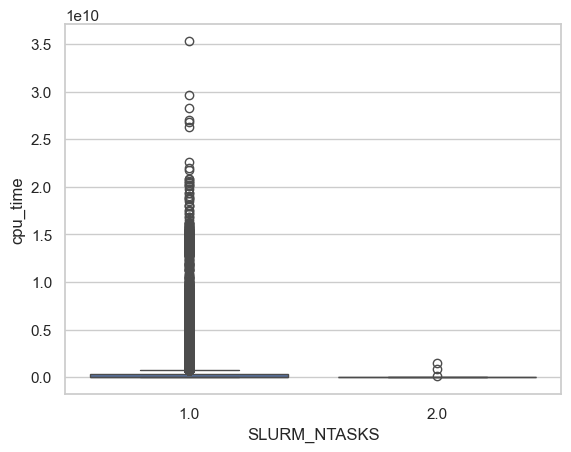

In [21]:
sns.boxplot(x='SLURM_NTASKS', y='cpu_time', data=df)

In [22]:
df['SLURM_NTASKS'].value_counts().sort_index()

SLURM_NTASKS
1.0    39933
2.0       17
Name: count, dtype: int64

In [23]:
df['SLURM_TASKS_PER_NODE'].value_counts().sort_index()

SLURM_TASKS_PER_NODE
1.0    39982
2.0       17
Name: count, dtype: int64

SLURM_NTASKS and SLURM_TASKS_PER_NODE are seemingly perfectly correlated in this data set. I'm at least removing one of them.

In [24]:
df['SLURM_NTASKS'].corr(df['SLURM_TASKS_PER_NODE'])

np.float64(1.0)

In [25]:
df = df.drop(columns=['SLURM_TASKS_PER_NODE'])

We're also dropping 'all_proc_tags'. After talking with Ian, we likely cannot use this data before running the jobs. They're not good for training and predicting.

In [26]:
df = df.drop(columns=['all_proc_tags'])

# Numerical Data  - Applying log, Skew/Outlier Detection + Clipping

It's time to do something with the numerical values to make them better for ML.

In [27]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
category_cols = df.select_dtypes(exclude="number").columns.tolist()

print("# numeric columns:", len(numeric_cols))
print("# category columns:", len(category_cols))

# numeric columns: 8
# category columns: 19


In [28]:
print("Numeric Columns", numeric_cols)
print("Category Columns", category_cols)

Numeric Columns ['read_bytes', 'write_bytes', 'time_waiting', 'cpu_time', 'duration', 'minflt', 'majflt', 'SLURM_NTASKS']
Category Columns ['start', 'end', 'tags', 'annotations', 'SLURM_JOB_ACCOUNT', 'SLURM_SCRIPT_CONTEXT', 'LOADEDMODULES', 'EPMT_JOB_TAGS', 'papiex-error', 'papiex-error-process-ids', 'parsed_EPMT_JOB_TAGS', 'exp_component', 'exp_fre_mod', 'exp_name', 'exp_time', 'exp_platform', 'exp_target', 'exp_seg_months', 'script_name']


In [29]:
df['exp_seg_months'] = df['exp_seg_months'].fillna("0").astype(int) # Not sure why this is a string... changing to int
df['exp_time'] = df['exp_time'].fillna("0").astype(int)

### Detecting Skew
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.skew.html

We're shooting for skews between -1 and 1, where 0 is like a normal distribution.
Wow, our data is really skewed.

In [30]:
df.skew(numeric_only=True).sort_values(ascending=False)

SLURM_NTASKS      48.447670
majflt            22.997401
time_waiting      16.604292
minflt            10.508033
read_bytes         9.927572
duration           9.221151
write_bytes        9.050809
cpu_time           6.503564
exp_time           0.075515
exp_seg_months    -2.381657
dtype: float64

In [31]:
# Try log transform - some are still skewed...
numerical_cols = df.select_dtypes(include="number").columns
df_log_trans = df.copy()
df_log_trans[numerical_cols] = np.log1p(df_log_trans[numerical_cols])
df_log_trans.skew(numeric_only=True).sort_values(ascending=False)

SLURM_NTASKS      48.447670
minflt             0.418819
majflt             0.381172
cpu_time           0.360376
duration           0.046672
time_waiting      -0.077002
write_bytes       -0.697371
read_bytes        -0.958198
exp_time          -2.006039
exp_seg_months    -2.496632
dtype: float64

In [32]:
df.describe()

,read_bytes,write_bytes,time_waiting,cpu_time,duration,minflt,majflt,SLURM_NTASKS,exp_time,exp_seg_months
count,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,4.000000e+04,39950.000000,4.000000e+04,40000.000000
mean,9.013787e+10,1.061092e+11,1.912810e+10,5.579547e+08,1.449861e+09,2.574613e+07,4.577521e+04,1.000426,9.965231e+06,10.647525
std,4.145771e+11,3.500005e+11,1.527242e+11,1.592365e+09,4.651422e+09,1.043087e+08,7.364212e+05,0.020624,8.910713e+06,3.705662
min,0.000000e+00,0.000000e+00,6.926000e+04,1.626600e+04,1.052534e+06,7.050000e+02,0.000000e+00,1.000000,0.000000e+00,0.000000
25%,1.060045e+07,8.978790e+08,1.214052e+09,2.595877e+07,1.155357e+08,1.452388e+06,3.000000e+00,1.000000,5.001010e+05,12.000000
50%,4.187238e+08,5.431673e+09,3.600179e+09,7.294562e+07,3.489228e+08,4.647822e+06,6.300000e+01,1.000000,9.740101e+06,12.000000
75%,2.462538e+10,5.466200e+10,9.238051e+09,3.123325e+08,9.056736e+08,1.277289e+07,3.892500e+02,1.000000,1.997010e+07,12.000000
max,7.814102e+12,6.462590e+12,5.649091e+12,3.527593e+10,1.677329e+11,2.141051e+09,3.404148e+07,2.000000,2.033010e+07,12.000000


In [33]:
# I'm not sure what to do with SLURM_TASKS_PER_NODE and SLURM_NTASKS. They seem to be mainly around 1, but some maxing at 2. I'll remove them.

#df_log_trans = df_log_trans.drop(columns=['SLURM_NTASKS', 'SLURM_TASKS_PER_NODE'])
numeric_cols = df_log_trans.select_dtypes(include="number").columns
df_log_trans.skew(numeric_only=True).sort_values(ascending=False)

SLURM_NTASKS      48.447670
minflt             0.418819
majflt             0.381172
cpu_time           0.360376
duration           0.046672
time_waiting      -0.077002
write_bytes       -0.697371
read_bytes        -0.958198
exp_time          -2.006039
exp_seg_months    -2.496632
dtype: float64

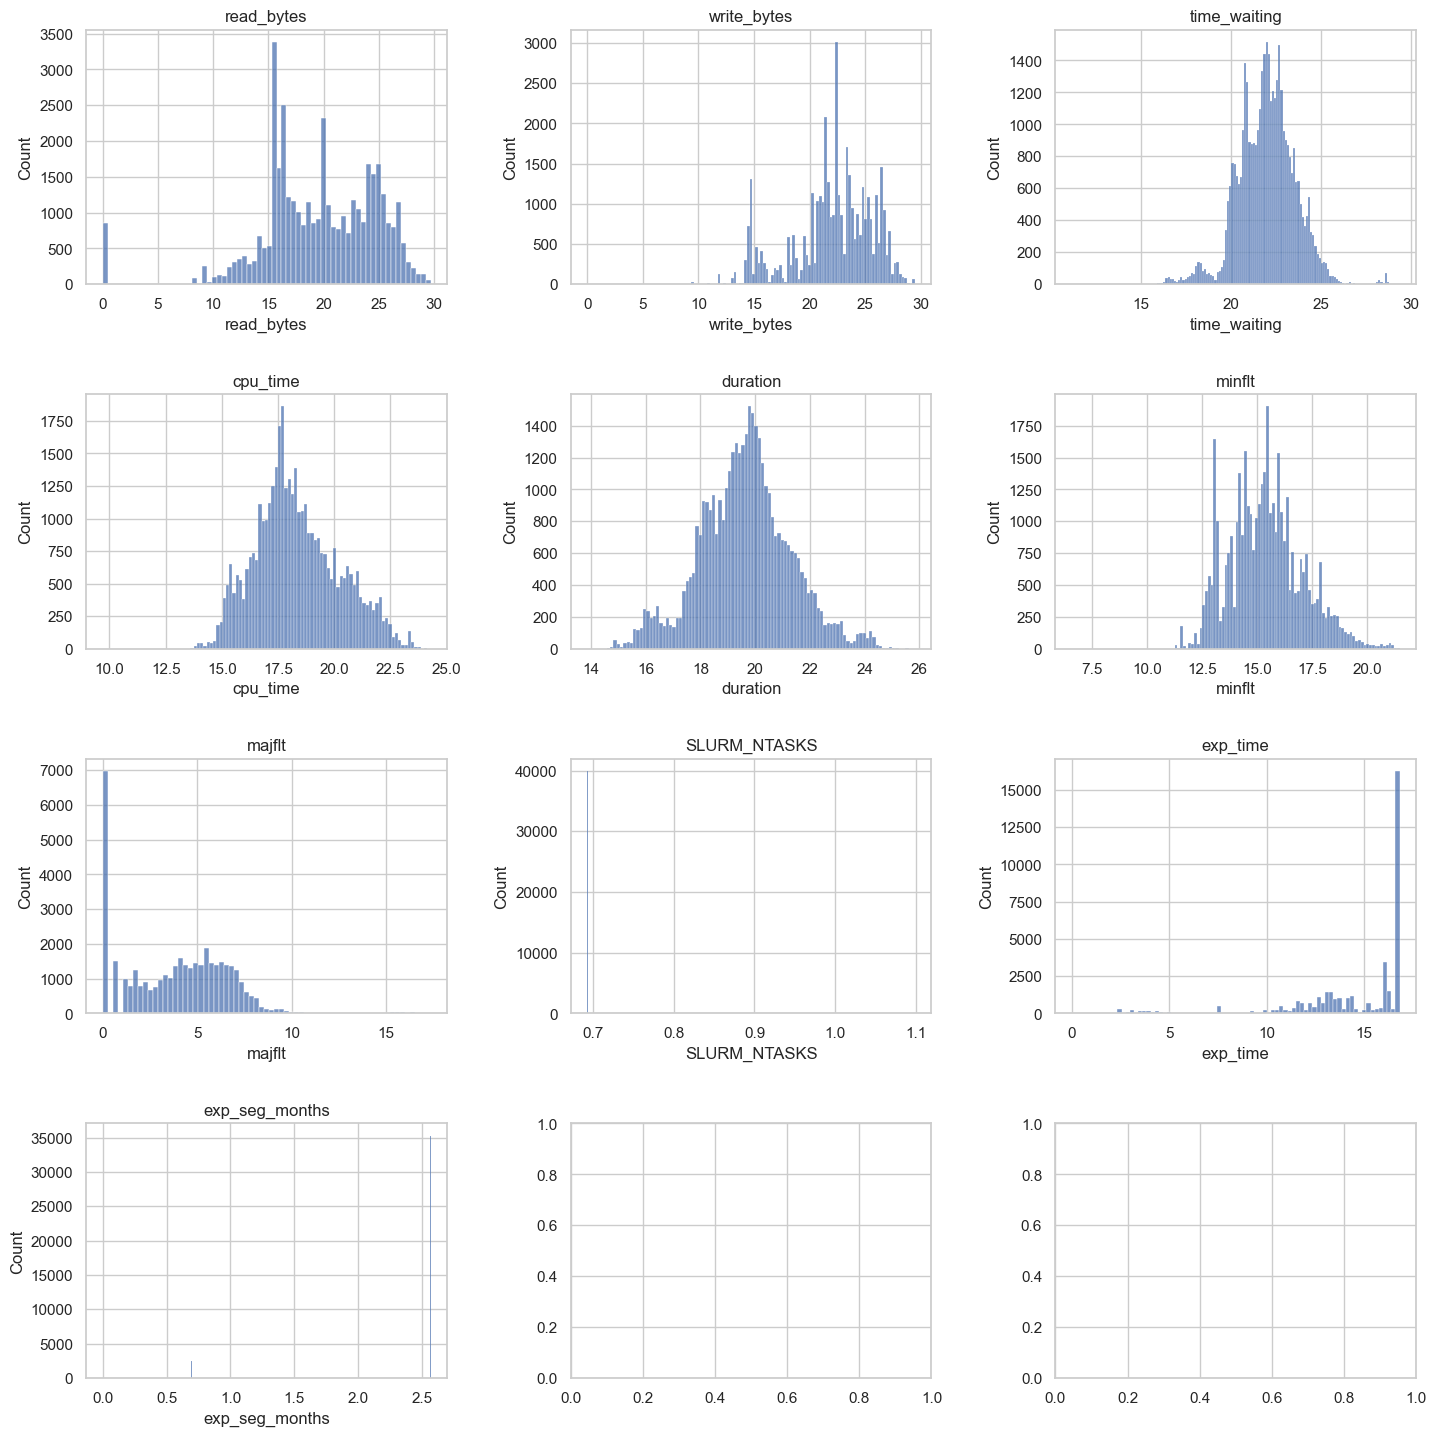

In [34]:
fig, axes = plt.subplots(4, 3, figsize=(15,15))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df_log_trans[col], ax=axes[i])
    #sns.histplot(df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout(pad=2.5)

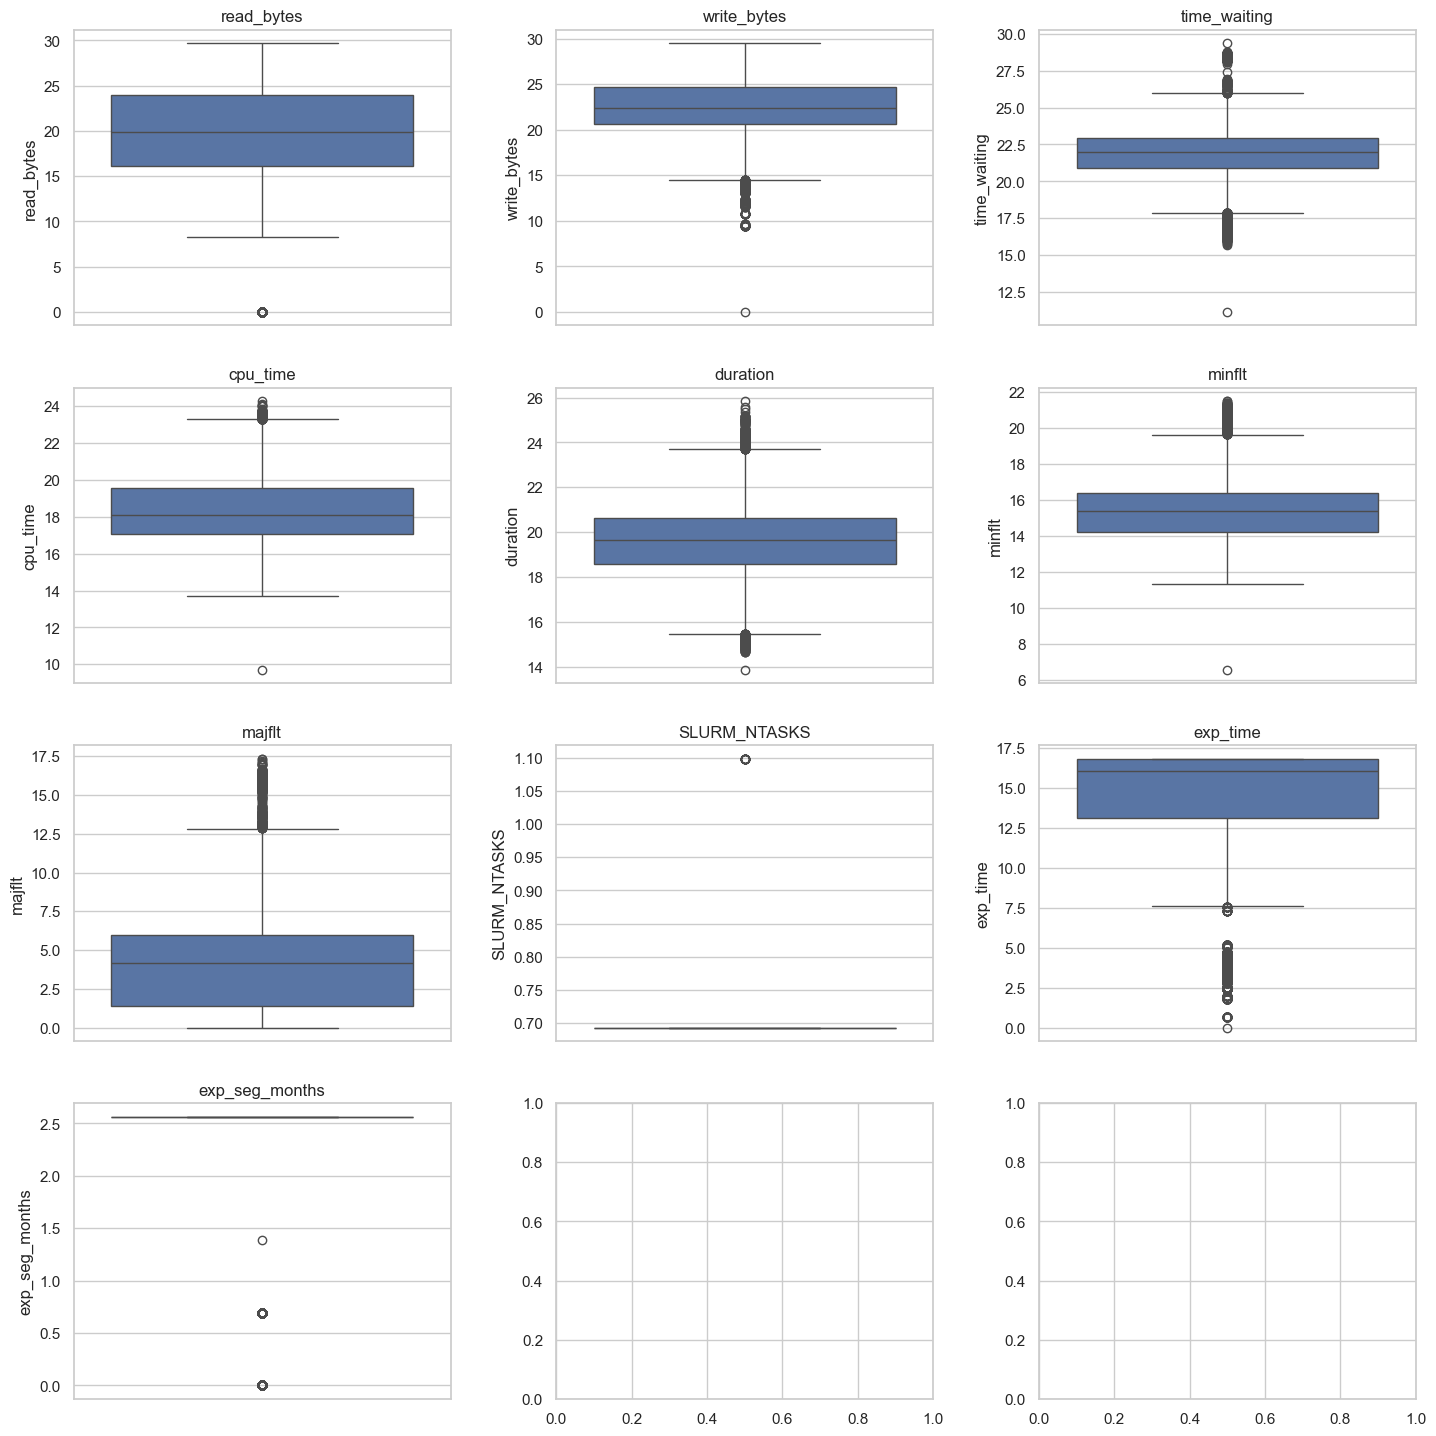

In [35]:
fig, axes = plt.subplots(4, 3, figsize=(15,15))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_log_trans[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout(pad=2.5)

#### Article on outlier detection: https://www.geeksforgeeks.org/data-analysis/detect-and-remove-the-outliers-using-python/

- Trying to remove rows that are too outside of the box and whiskers.

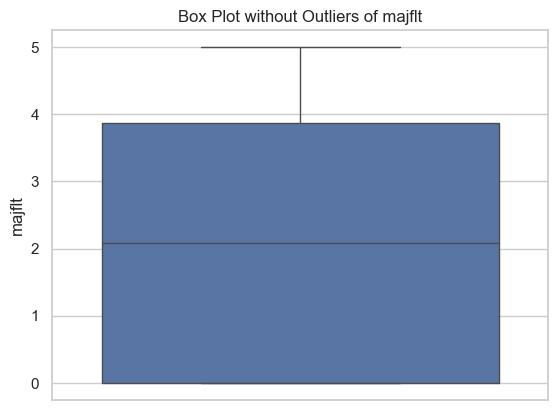

count    40000.000000
mean         3.910515
std          2.787634
min          0.000000
25%          1.386294
50%          4.158883
75%          5.966787
max         17.343090
Name: majflt, dtype: float64

In [36]:
# Outlier detection on 'majflt'
def removal_box_plot(df, column, threshold):
    removed_outliers = df[df[column] <= threshold]

    sns.boxplot(removed_outliers[column])
    plt.title(f'Box Plot without Outliers of {column}')
    plt.show()
    return removed_outliers

no_outliers = removal_box_plot(df_log_trans, 'majflt', 5)
df_log_trans['majflt'].describe()

If I'm still trying to predict cpu_time, then it looks okay to me to remove the highest skewed columns that are the least correlated to the cpu_time.

In [37]:
df_log_trans.describe()

,read_bytes,write_bytes,time_waiting,cpu_time,duration,minflt,majflt,SLURM_NTASKS,exp_time,exp_seg_months
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,39950.000000,40000.000000,40000.000000
mean,19.543025,22.091269,21.980751,18.346014,19.644017,15.380868,3.910515,0.693320,14.518486,2.305006
std,5.238274,3.575576,1.580254,1.867423,1.656084,1.683345,2.787634,0.008362,3.186076,0.721335
min,0.000000,0.000000,11.145637,9.696894,13.866712,6.559615,0.000000,0.693147,0.000000,0.000000
25%,16.176407,20.615546,20.917229,17.072020,18.565090,14.188720,1.386294,0.693147,13.122567,2.564949
50%,19.852722,22.415513,22.004250,18.105225,19.670361,15.351910,4.158883,0.693147,16.091762,2.564949
75%,23.927043,24.724435,22.946597,19.559579,20.624190,16.362836,5.966787,0.693147,16.809747,2.564949
max,29.686951,29.497051,29.362516,24.286467,25.845639,21.484563,17.343090,1.098612,16.827613,2.564949


In [38]:
df_clean = df_log_trans
df_clean.corr(numeric_only=True)['cpu_time'].sort_values(ascending=False)

cpu_time          1.000000
duration          0.893371
minflt            0.858339
write_bytes       0.824962
time_waiting      0.766093
read_bytes        0.727871
majflt            0.559370
exp_seg_months    0.226815
exp_time          0.037140
SLURM_NTASKS     -0.017983
Name: cpu_time, dtype: float64

In [39]:
df_clean.head()

,read_bytes,write_bytes,time_waiting,cpu_time,duration,start,end,minflt,majflt,tags,...,papiex-error-process-ids,parsed_EPMT_JOB_TAGS,exp_component,exp_fre_mod,exp_name,exp_time,exp_platform,exp_target,exp_seg_months,script_name
0,25.686867,25.196333,21.178675,19.315824,21.024541,2026-01-28 09:15:39.211909,2026-01-28 09:38:10.792654,16.595646,4.499810,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,NaN,"{'exp_component': 'ocean_rho2', 'exp_fre_mod':...",ocean_rho2,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,12.874164,gfdl.ncrc5-intel23_2_0,repro-openmp,2.564949,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
1,26.997183,26.491772,21.198902,20.519708,21.712899,2026-01-28 09:15:39.224952,2026-01-28 10:00:29.471986,18.024777,4.564348,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,NaN,"{'exp_component': 'ocean_z', 'exp_fre_mod': '/...",ocean_z,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,12.874164,gfdl.ncrc5-intel23_2_0,repro-openmp,2.564949,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
2,23.754981,23.460674,20.976034,18.079300,20.821709,2026-01-28 09:15:39.234004,2026-01-28 09:34:02.685979,15.533278,0.693147,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,NaN,"{'exp_component': 'ocean', 'exp_fre_mod': '/ho...",ocean,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,12.874164,gfdl.ncrc5-intel23_2_0,repro-openmp,2.564949,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
3,14.739389,16.031551,20.782174,16.571821,20.468218,2026-01-28 09:15:39.267702,2026-01-28 09:28:34.147049,14.420871,2.302585,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,NaN,"{'exp_component': 'ocean_scalar', 'exp_fre_mod...",ocean_scalar,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,12.874164,gfdl.ncrc5-intel23_2_0,repro-openmp,2.564949,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
4,24.662084,24.407498,21.604099,19.514315,21.228419,2026-01-28 09:15:39.495806,2026-01-28 09:43:16.734767,16.135398,0.000000,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,...,NaN,"{'exp_component': 'ice', 'exp_fre_mod': '/home...",ice,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,12.874164,gfdl.ncrc5-intel23_2_0,repro-openmp,2.564949,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...


### IQR - Trying to address outliers
* Compute Q1 (25th percentile), Q3 (75th percentile), IQR (Q3-Q1)
* Pick some outlier thresholds, suggested
  * lower: Q1-1.5*IQR
  * upper: Q3-1.5*IQR
* Flag outliers
* Potentially remove/clip outliers?

In [40]:
numeric_cols = df_clean.select_dtypes(include="number").columns.tolist()
numeric_cols
q1 = df_clean[numeric_cols].quantile(0.25)
q3 = df_clean[numeric_cols].quantile(0.75)
iqr = q3-q1
iqr

read_bytes        7.750636
write_bytes       4.108889
time_waiting      2.029367
cpu_time          2.487559
duration          2.059099
minflt            2.174116
majflt            4.580493
SLURM_NTASKS      0.000000
exp_time          3.687179
exp_seg_months    0.000000
dtype: float64

In [41]:
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr
lower, upper

(read_bytes         4.550452
 write_bytes       14.452213
 time_waiting      17.873178
 cpu_time          13.340682
 duration          15.476442
 minflt            10.927547
 majflt            -5.484445
 SLURM_NTASKS       0.693147
 exp_time           7.591798
 exp_seg_months     2.564949
 dtype: float64,
 read_bytes        35.552998
 write_bytes       30.887767
 time_waiting      25.990648
 cpu_time          23.290917
 duration          23.712838
 minflt            19.624009
 majflt            12.837526
 SLURM_NTASKS       0.693147
 exp_time          22.340516
 exp_seg_months     2.564949
 dtype: float64)

In [42]:
outliers = (df_clean[numeric_cols] < lower) | (df_clean[numeric_cols] > upper)
outliers.sum()

read_bytes         850
write_bytes        795
time_waiting       753
cpu_time           208
duration           824
minflt             461
majflt             281
SLURM_NTASKS        17
exp_time          1813
exp_seg_months    4711
dtype: int64

In [43]:
outliers.sum(axis=1)

0        0
1        0
2        0
3        0
4        0
        ..
39995    0
39996    0
39997    0
39998    0
39999    0
Length: 40000, dtype: int64

In [44]:
# Try clipping data out of the upper/lower bounds... basically restricting the outliers a bit?

df_within_bounds = df_clean.copy()
df_within_bounds[numeric_cols] = df_within_bounds[numeric_cols].clip(lower=lower, upper=upper, axis=1)
df_within_bounds.describe()

,read_bytes,write_bytes,time_waiting,cpu_time,duration,minflt,majflt,SLURM_NTASKS,exp_time,exp_seg_months
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,39950.000000,40000.000000,4.000000e+04
mean,19.639722,22.116485,21.980490,18.345335,19.639494,15.372184,3.894652,0.693147,14.701781,2.564949e+00
std,4.908216,3.511483,1.514263,1.864980,1.633205,1.657578,2.727846,0.000000,2.603478,4.440948e-16
min,4.550452,14.452213,17.873178,13.340682,15.476442,10.927547,0.000000,0.693147,7.591798,2.564949e+00
25%,16.176407,20.615546,20.917229,17.072020,18.565090,14.188720,1.386294,0.693147,13.122567,2.564949e+00
50%,19.852722,22.415513,22.004250,18.105225,19.670361,15.351910,4.158883,0.693147,16.091762,2.564949e+00
75%,23.927043,24.724435,22.946597,19.559579,20.624190,16.362836,5.966787,0.693147,16.809747,2.564949e+00
max,29.686951,29.497051,25.990648,23.290917,23.712838,19.624009,12.837526,0.693147,16.827613,2.564949e+00


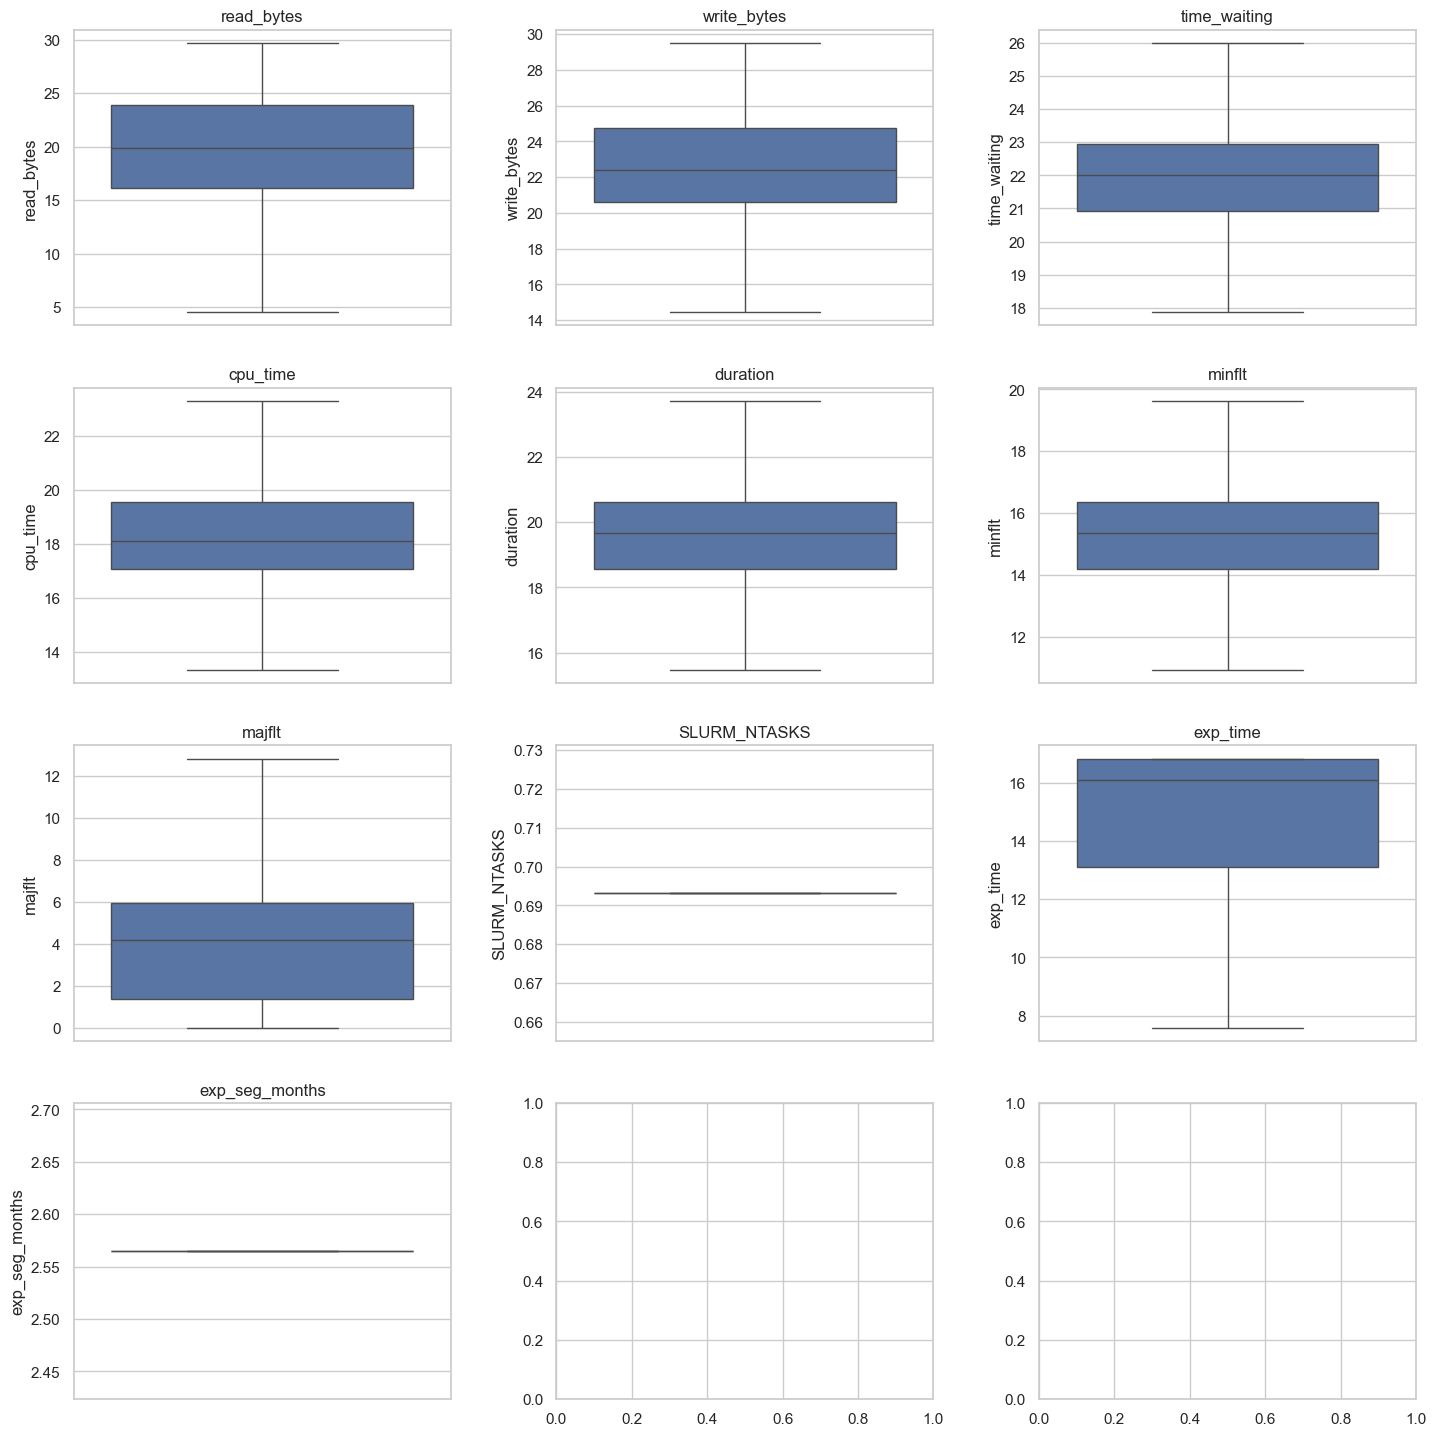

In [45]:
fig, axes = plt.subplots(4, 3, figsize=(15,15))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_within_bounds[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout(pad=2.5)

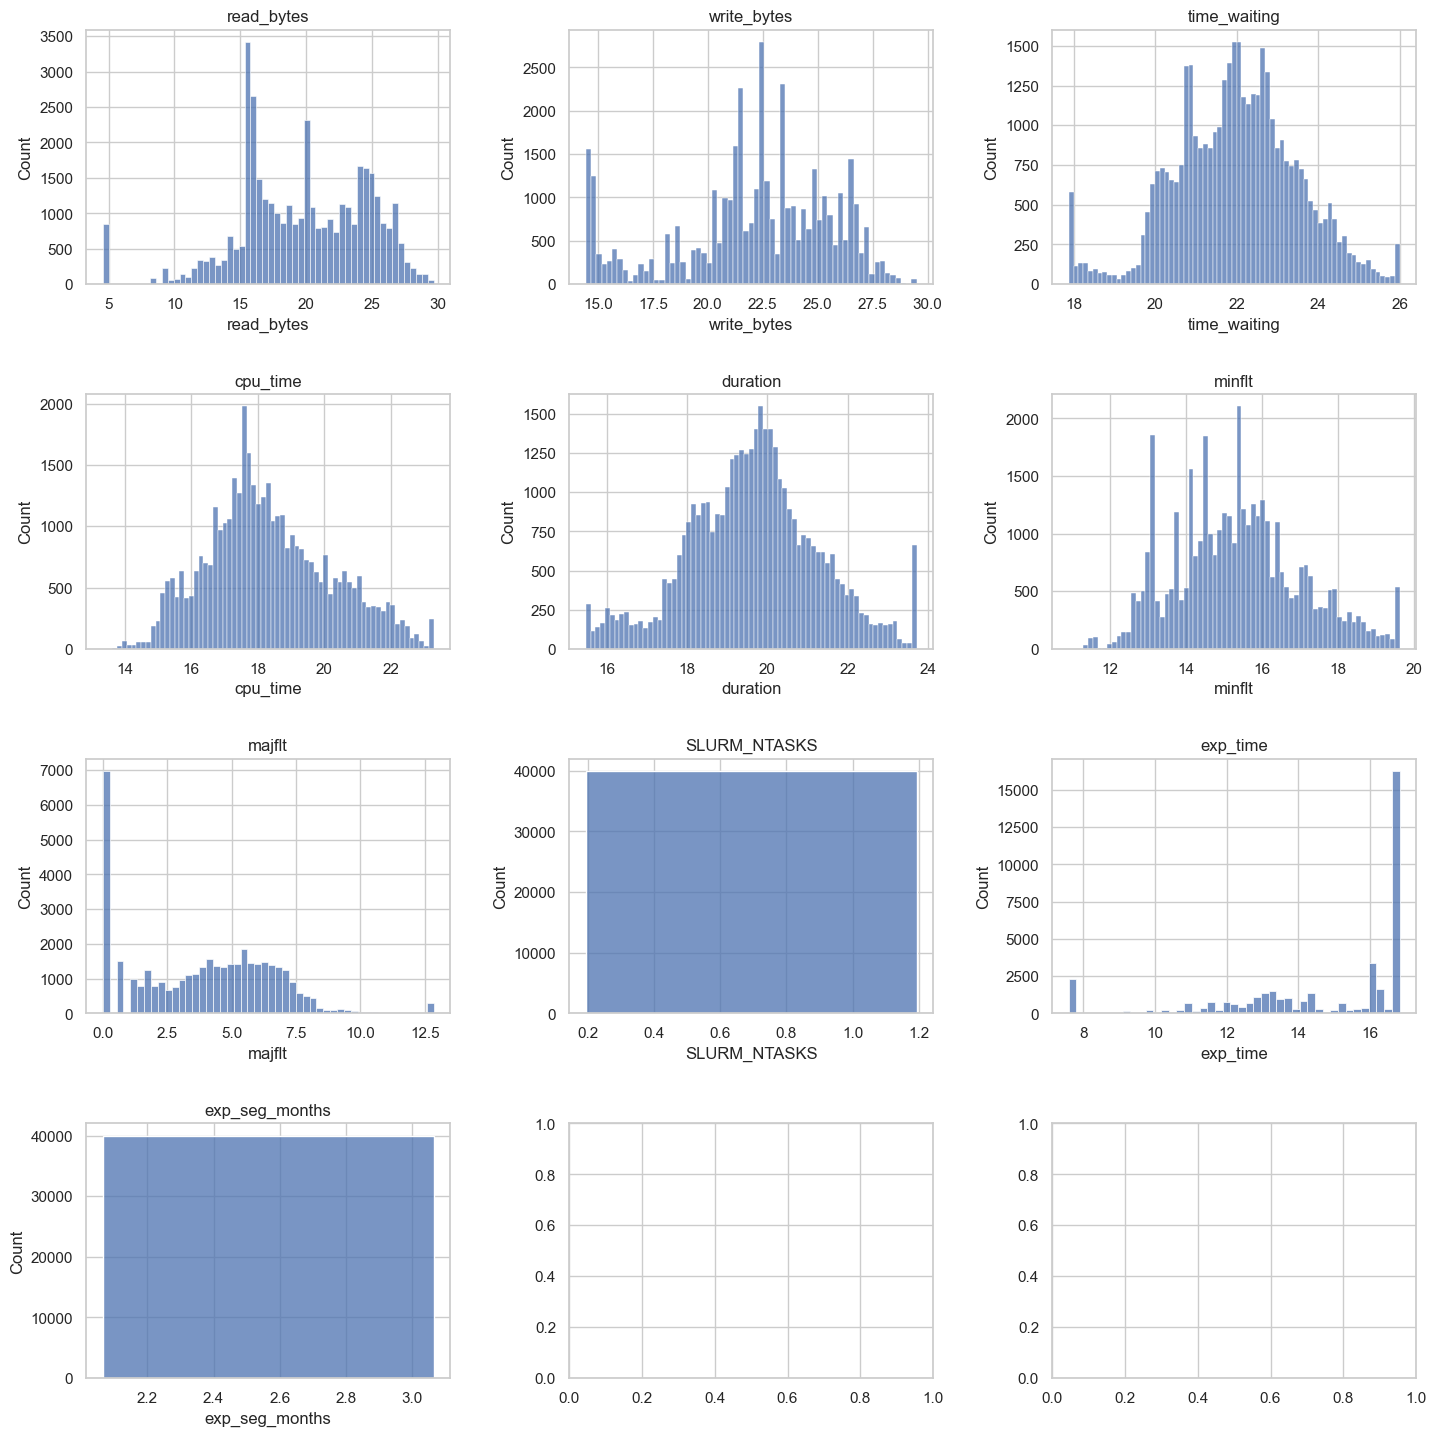

In [46]:
fig, axes = plt.subplots(4, 3, figsize=(15,15))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df_within_bounds[col], ax=axes[i])
    #sns.histplot(df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout(pad=2.5)

In [47]:
df_clean=df_within_bounds

In [48]:
# Reverting SLURM_NTASKS and exp_seg_months because they're really not useful after clipping
df_clean['SLURM_NTASKS'] = df['SLURM_NTASKS']
df_clean['exp_seg_months'] = df['exp_seg_months']

# One-hot Encoding the Non-numerical Data

In [49]:
from sklearn.preprocessing import OneHotEncoder

category_cols

['start',
 'end',
 'tags',
 'annotations',
 'SLURM_JOB_ACCOUNT',
 'SLURM_SCRIPT_CONTEXT',
 'LOADEDMODULES',
 'EPMT_JOB_TAGS',
 'papiex-error',
 'papiex-error-process-ids',
 'parsed_EPMT_JOB_TAGS',
 'exp_component',
 'exp_fre_mod',
 'exp_name',
 'exp_time',
 'exp_platform',
 'exp_target',
 'exp_seg_months',
 'script_name']

In [50]:
df_clean[category_cols].head()

,start,end,tags,annotations,SLURM_JOB_ACCOUNT,SLURM_SCRIPT_CONTEXT,LOADEDMODULES,EPMT_JOB_TAGS,papiex-error,papiex-error-process-ids,parsed_EPMT_JOB_TAGS,exp_component,exp_fre_mod,exp_name,exp_time,exp_platform,exp_target,exp_seg_months,script_name
0,2026-01-28 09:15:39.211909,2026-01-28 09:38:10.792654,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,{'EPMT_JOB_TAGS': 'exp_component:ocean_rho2;ex...,gfdl_sd,prolog_task,epmt/4.9.2,exp_component:ocean_rho2;exp_fre_mod:/home/fms...,NaN,NaN,"{'exp_component': 'ocean_rho2', 'exp_fre_mod':...",ocean_rho2,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,12.874164,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
1,2026-01-28 09:15:39.224952,2026-01-28 10:00:29.471986,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,{'EPMT_JOB_TAGS': 'exp_component:ocean_z;exp_f...,gfdl_sd,prolog_task,epmt/4.9.2,exp_component:ocean_z;exp_fre_mod:/home/fms/lo...,NaN,NaN,"{'exp_component': 'ocean_z', 'exp_fre_mod': '/...",ocean_z,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,12.874164,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
2,2026-01-28 09:15:39.234004,2026-01-28 09:34:02.685979,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,{'EPMT_JOB_TAGS': 'exp_component:ocean;exp_fre...,gfdl_sd,prolog_task,epmt/4.9.2,exp_component:ocean;exp_fre_mod:/home/fms/loca...,NaN,NaN,"{'exp_component': 'ocean', 'exp_fre_mod': '/ho...",ocean,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,12.874164,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
3,2026-01-28 09:15:39.267702,2026-01-28 09:28:34.147049,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,{'EPMT_JOB_TAGS': 'exp_component:ocean_scalar;...,gfdl_sd,prolog_task,epmt/4.9.2,exp_component:ocean_scalar;exp_fre_mod:/home/f...,NaN,NaN,"{'exp_component': 'ocean_scalar', 'exp_fre_mod...",ocean_scalar,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,12.874164,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
4,2026-01-28 09:15:39.495806,2026-01-28 09:43:16.734767,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,{'EPMT_JOB_TAGS': 'exp_component:ice;exp_fre_m...,gfdl_sd,prolog_task,epmt/4.9.2,exp_component:ice;exp_fre_mod:/home/fms/local/...,NaN,NaN,"{'exp_component': 'ice', 'exp_fre_mod': '/home...",ice,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,12.874164,gfdl.ncrc5-intel23_2_0,repro-openmp,12,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...


### Removing some columns
There's a bit of clean up here. Some of the columns were expanded out already. Some of the values (like the papiex columns) seems to have a lot of NaN values. So, I'll drop some of these here.

In [51]:
df_clean.drop(columns=['annotations', 'papiex-error', 'papiex-error-process-ids', 'parsed_EPMT_JOB_TAGS', 'EPMT_JOB_TAGS'], inplace=True)

In [52]:
category_cols = df_clean.select_dtypes(exclude="number").columns.tolist()
df_clean[category_cols].head()

,start,end,tags,SLURM_JOB_ACCOUNT,SLURM_SCRIPT_CONTEXT,LOADEDMODULES,exp_component,exp_fre_mod,exp_name,exp_platform,exp_target,script_name
0,2026-01-28 09:15:39.211909,2026-01-28 09:38:10.792654,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,gfdl_sd,prolog_task,epmt/4.9.2,ocean_rho2,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
1,2026-01-28 09:15:39.224952,2026-01-28 10:00:29.471986,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,gfdl_sd,prolog_task,epmt/4.9.2,ocean_z,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
2,2026-01-28 09:15:39.234004,2026-01-28 09:34:02.685979,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,gfdl_sd,prolog_task,epmt/4.9.2,ocean,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
3,2026-01-28 09:15:39.267702,2026-01-28 09:28:34.147049,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,gfdl_sd,prolog_task,epmt/4.9.2,ocean_scalar,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...
4,2026-01-28 09:15:39.495806,2026-01-28 09:43:16.734767,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,gfdl_sd,prolog_task,epmt/4.9.2,ice,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2X,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384_OM4p08_Ctrl_1990_A14_IC0101_1PctTo2...


In [53]:
df_clean["exp_component"]

0                ocean_rho2
1                   ocean_z
2                     ocean
3              ocean_scalar
4                       ice
                ...        
39995       ocean_monthly_z
39996    ocean_monthly_rho0
39997    ocean_monthly_rho2
39998        ocean_annual_z
39999          ocean_annual
Name: exp_component, Length: 40000, dtype: str

In [54]:
numeric_cols = df_clean.select_dtypes(include="number").columns.tolist()
category_cols = df_clean.select_dtypes(exclude="number").columns.tolist()

print("# numeric columns:", len(numeric_cols))
print("# category columns:", len(category_cols))

category_cols

# numeric columns: 10
# category columns: 12


['start',
 'end',
 'tags',
 'SLURM_JOB_ACCOUNT',
 'SLURM_SCRIPT_CONTEXT',
 'LOADEDMODULES',
 'exp_component',
 'exp_fre_mod',
 'exp_name',
 'exp_platform',
 'exp_target',
 'script_name']

In [55]:
# Find the NaNs and replace with non-NaNs
df_clean.isna().sum()

read_bytes                 0
write_bytes                0
time_waiting               0
cpu_time                   0
duration                   0
start                      0
end                        0
minflt                     0
majflt                     0
tags                       0
SLURM_JOB_ACCOUNT          1
SLURM_NTASKS              50
SLURM_SCRIPT_CONTEXT       1
LOADEDMODULES              0
exp_component              1
exp_fre_mod             2280
exp_name                   1
exp_time                   0
exp_platform               1
exp_target                 1
exp_seg_months             0
script_name                1
dtype: int64

In [56]:
df_clean['SLURM_JOB_ACCOUNT'] = df_clean['SLURM_JOB_ACCOUNT'].fillna("Missing")
df_clean['SLURM_NTASKS'] = df_clean['SLURM_NTASKS'].fillna(0)
df_clean['SLURM_SCRIPT_CONTEXT'] = df_clean['SLURM_SCRIPT_CONTEXT'].fillna("Missing")
df_clean['exp_seg_months'] = df_clean['exp_seg_months'].fillna(-1)
df_clean['exp_fre_mod'] = df_clean['exp_fre_mod'].fillna("Missing")
df_clean = df_clean.dropna(subset=["exp_name"])

In [57]:
len(df_clean) # Lost one out of 40k

39999

In [58]:
# Find the NaNs
df_clean.isna().sum()

read_bytes              0
write_bytes             0
time_waiting            0
cpu_time                0
duration                0
start                   0
end                     0
minflt                  0
majflt                  0
tags                    0
SLURM_JOB_ACCOUNT       0
SLURM_NTASKS            0
SLURM_SCRIPT_CONTEXT    0
LOADEDMODULES           0
exp_component           0
exp_fre_mod             0
exp_name                0
exp_time                0
exp_platform            0
exp_target              0
exp_seg_months          0
script_name             0
dtype: int64

# TODO - I probably shouldn't be cleaning up all the data like this --- only on TRAINING DATA (please fix this)

In [59]:
# Try to reduce the cardinality of the exp_component - just take the first one
df_clean['exp_component'] = (
    df_clean['exp_component'].apply(lambda x: '_'.join(x.split('_')[:1]))
)

In [60]:
df_clean['exp_component'].unique()

<StringArray>
[     'ocean',        'ice', 'refineDiag',   'analysis',      'river',
       'land',       'soil',       'fire',      'atmos',     'tracer',
    'aerosol',    'iceberg',      'bergs',        'ocn',      'LUmip',
           '']
Length: 16, dtype: str

In [61]:
# Try to reduce the cardinality of the script_name - just take the first two interesting parts
df_clean['script_name'] = (
    #df_clean['script_name'].apply(lambda x: '_'.join(x.split(r"_.-")[:2]))
    df_clean['script_name']
        .str.split(r"[_.-]", regex=True)
        .str[:2]
        .str.join('_')
)

In [62]:
df_clean['script_name'].unique()

array(['SPEAR_c384', 'om5_b11', 'abrupt_4xCO2', 'van_o3analysis',
       'van_mon', 'CM4_OM5', 'deike_amip', 'Simple_noFastSpinup',
       'const_ctrl', 'c384L65_am5f11d10r1', 'ESM4_5', 'OM4p25_jra',
       'GLBc0p08_jra', 'c384L65_am5f11d10r0', 'atw_atmos',
       'i20220101_OTA', 'frepp_pyferret', 'frepp_1by1', 'c384L33_am4p0',
       'NWA12_COBALT', 'LM4p0_C384', 'om5_b13c', 'iCM4_5', 'van_ch4',
       'bw_atmos', 'tk_atmos', 'pjk_atmos', 'bw_cru', 'sak_atmos',
       'cjg_atmos', 'lwh_atmos', 'yim_aer', 'frepp_atw', 'frepp_pcmdi',
       'proto4_0', 'aerosol_monthly', 'c96L33_am5a0', 'bw_box', 'om5_b12',
       'iOM4GrAIS_JRA', 'c96L65_am5f8d5r0z', 'wheeler_kiladis',
       'frepp_jwd', 'c96L65_am5f11d12r0', 'bw_diurnal', 'frepp_tropical',
       'ARC12_BGC', 'NEP_GFDL', 'c96L65_am5f11d11r0lm4p2',
       'c384L65_am5f11d11r0lm4p2', 'NEP10k_202507', 'NEP10_COBALT',
       'SPEAR_c96', 'SPEAR_nmme', 'c96L65_am5f8d6r3', 'i20260201_OTA',
       'Simple_spinup', 'c192L33_CM4X', 'c96L65_

In [63]:
# Try to reduce the cardinality of the script_name - just take the first two interesting parts
df_clean['exp_name'] = (
    #df_clean['script_name'].apply(lambda x: '_'.join(x.split(r"_.-")[:2]))
    df_clean['exp_name']
        .str.split(r"[_.-]", regex=True)
        .str[:2]
        .str.join('_')
)

In [64]:
df_clean['exp_name'].unique()

array(['SPEAR_c384', 'om5_b11', 'abrupt_4xCO2', 'CM4_OM5', 'deike_amip',
       'Simple_noFastSpinup', 'const_ctrl', 'c384L65_am5f11d10r1',
       'ESM4_5', 'OM4p25_jra', 'GLBc0p08_jra', 'c384L65_am5f11d10r0',
       'i20220101_OTA', 'c384L33_am4p0', 'NWA12_COBALT', 'LM4p0_C384',
       'om5_b13c', 'iCM4_5', 'proto4_0', 'c96L33_am5a0', 'om5_b12',
       'iOM4GrAIS_JRA', 'c96L65_am5f8d5r0z', 'c96L65_am5f11d12r0',
       'ARC12_BGC', 'NEP_GFDL', 'c96L65_am5f11d11r0lm4p2',
       'c384L65_am5f11d11r0lm4p2', 'NEP10k_202507', 'NEP10_COBALT',
       'SPEAR_c96', 'SPEAR_nmme', 'c96L65_am5f8d6r3', 'i20260201_OTA',
       'Simple_spinup', 'c192L33_CM4X', 'c96L65_am5f8d5r2',
       'c96L65_am5f11d10r1', 'i20260101_OTA', 'i20240101_OTA',
       'mem5_therm', 'mem6_surf', 'mem3_therm', 'mem2_surf', 'mem3_surf',
       'mem2_mid', 'mem6_mid', 'mem4_surf', 'mem5_surf', 'ESM4_5v14',
       'jaegle_amip', 'mem4_therm', 'mem6_therm', 'mem5_mid',
       'mem2_therm', 'mem3_mid', 'mem4_mid', 'proto4_c48l

In [65]:
df_clean[category_cols].head()

,start,end,tags,SLURM_JOB_ACCOUNT,SLURM_SCRIPT_CONTEXT,LOADEDMODULES,exp_component,exp_fre_mod,exp_name,exp_platform,exp_target,script_name
0,2026-01-28 09:15:39.211909,2026-01-28 09:38:10.792654,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,gfdl_sd,prolog_task,epmt/4.9.2,ocean,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384
1,2026-01-28 09:15:39.224952,2026-01-28 10:00:29.471986,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,gfdl_sd,prolog_task,epmt/4.9.2,ocean,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384
2,2026-01-28 09:15:39.234004,2026-01-28 09:34:02.685979,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,gfdl_sd,prolog_task,epmt/4.9.2,ocean,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384
3,2026-01-28 09:15:39.267702,2026-01-28 09:28:34.147049,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,gfdl_sd,prolog_task,epmt/4.9.2,ocean,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384
4,2026-01-28 09:15:39.495806,2026-01-28 09:43:16.734767,{'exp_name': 'SPEAR_c384_OM4p08_Ctrl_1990_A14_...,gfdl_sd,prolog_task,epmt/4.9.2,ice,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384


In [66]:
# Running out of time. Removing start, end, and tags for now.
df_clean = df_clean.drop(columns=['start', 'end', 'tags'])
category_cols = df_clean.select_dtypes(exclude="number").columns.tolist()
df_clean[category_cols].head()

,SLURM_JOB_ACCOUNT,SLURM_SCRIPT_CONTEXT,LOADEDMODULES,exp_component,exp_fre_mod,exp_name,exp_platform,exp_target,script_name
0,gfdl_sd,prolog_task,epmt/4.9.2,ocean,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384
1,gfdl_sd,prolog_task,epmt/4.9.2,ocean,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384
2,gfdl_sd,prolog_task,epmt/4.9.2,ocean,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384
3,gfdl_sd,prolog_task,epmt/4.9.2,ocean,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384
4,gfdl_sd,prolog_task,epmt/4.9.2,ice,/home/fms/local/opt/fre-commands/bronx-23,SPEAR_c384,gfdl.ncrc5-intel23_2_0,repro-openmp,SPEAR_c384


In [67]:
df_clean['exp_seg_months'].unique()

array([12,  0,  1,  3])

In [68]:
ohe = OneHotEncoder(sparse_output=False)
ohe_data = ohe.fit_transform(df_clean[category_cols])
ohe_cols = ohe.get_feature_names_out(category_cols)
df_categorical = pd.DataFrame(ohe_data, columns=ohe_cols)
df_categorical.head()

,SLURM_JOB_ACCOUNT_cefi,SLURM_JOB_ACCOUNT_gfdl_a,SLURM_JOB_ACCOUNT_gfdl_b,SLURM_JOB_ACCOUNT_gfdl_f,SLURM_JOB_ACCOUNT_gfdl_m,SLURM_JOB_ACCOUNT_gfdl_o,SLURM_JOB_ACCOUNT_gfdl_sd,SLURM_JOB_ACCOUNT_gfdl_w,SLURM_SCRIPT_CONTEXT_prolog_task,LOADEDMODULES_epmt/4.9.2,...,script_name_pjk_atmos,script_name_proto4_0,script_name_proto4_c48l33o1degSPEAR,script_name_sak_atmos,script_name_tk_atmos,script_name_van_ch4,script_name_van_mon,script_name_van_o3analysis,script_name_wheeler_kiladis,script_name_yim_aer
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


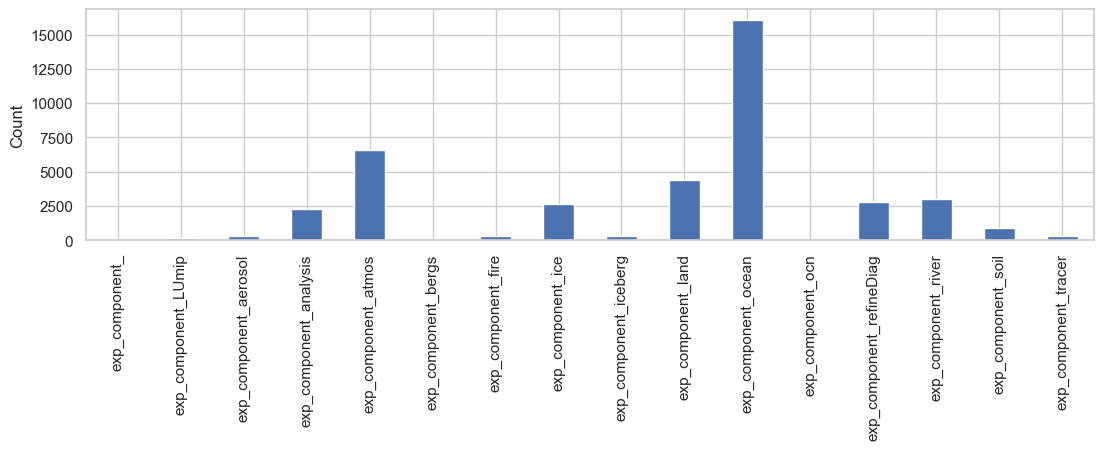

In [69]:
def plot_one_category(df_categorical, single_category):
    startswith = f"{single_category}_"
    cols = [c for c in df_categorical.columns if c.startswith(startswith)]
    df_categorical[cols].sum().plot(kind='bar', figsize=(13,3))
    plt.ylabel('Count')
    plt.show()
    
plot_one_category(df_categorical, "exp_component")

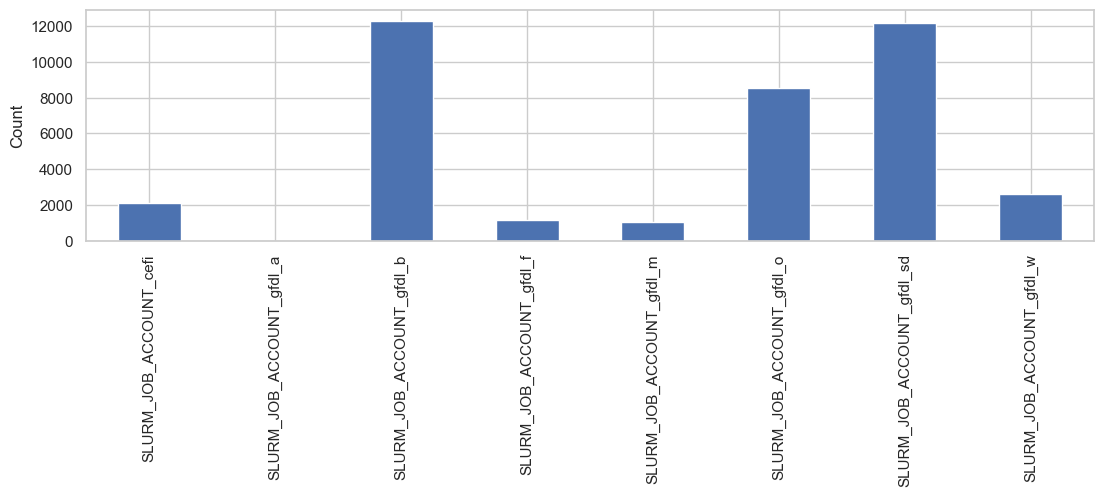

In [70]:
plot_one_category(df_categorical, "SLURM_JOB_ACCOUNT")

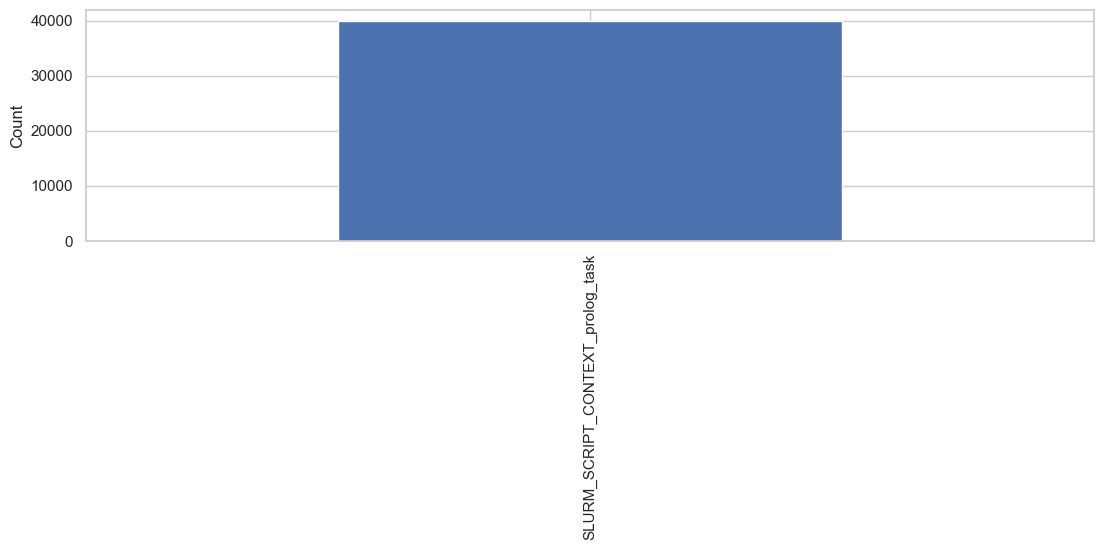

In [71]:
plot_one_category(df_categorical, "SLURM_SCRIPT_CONTEXT")

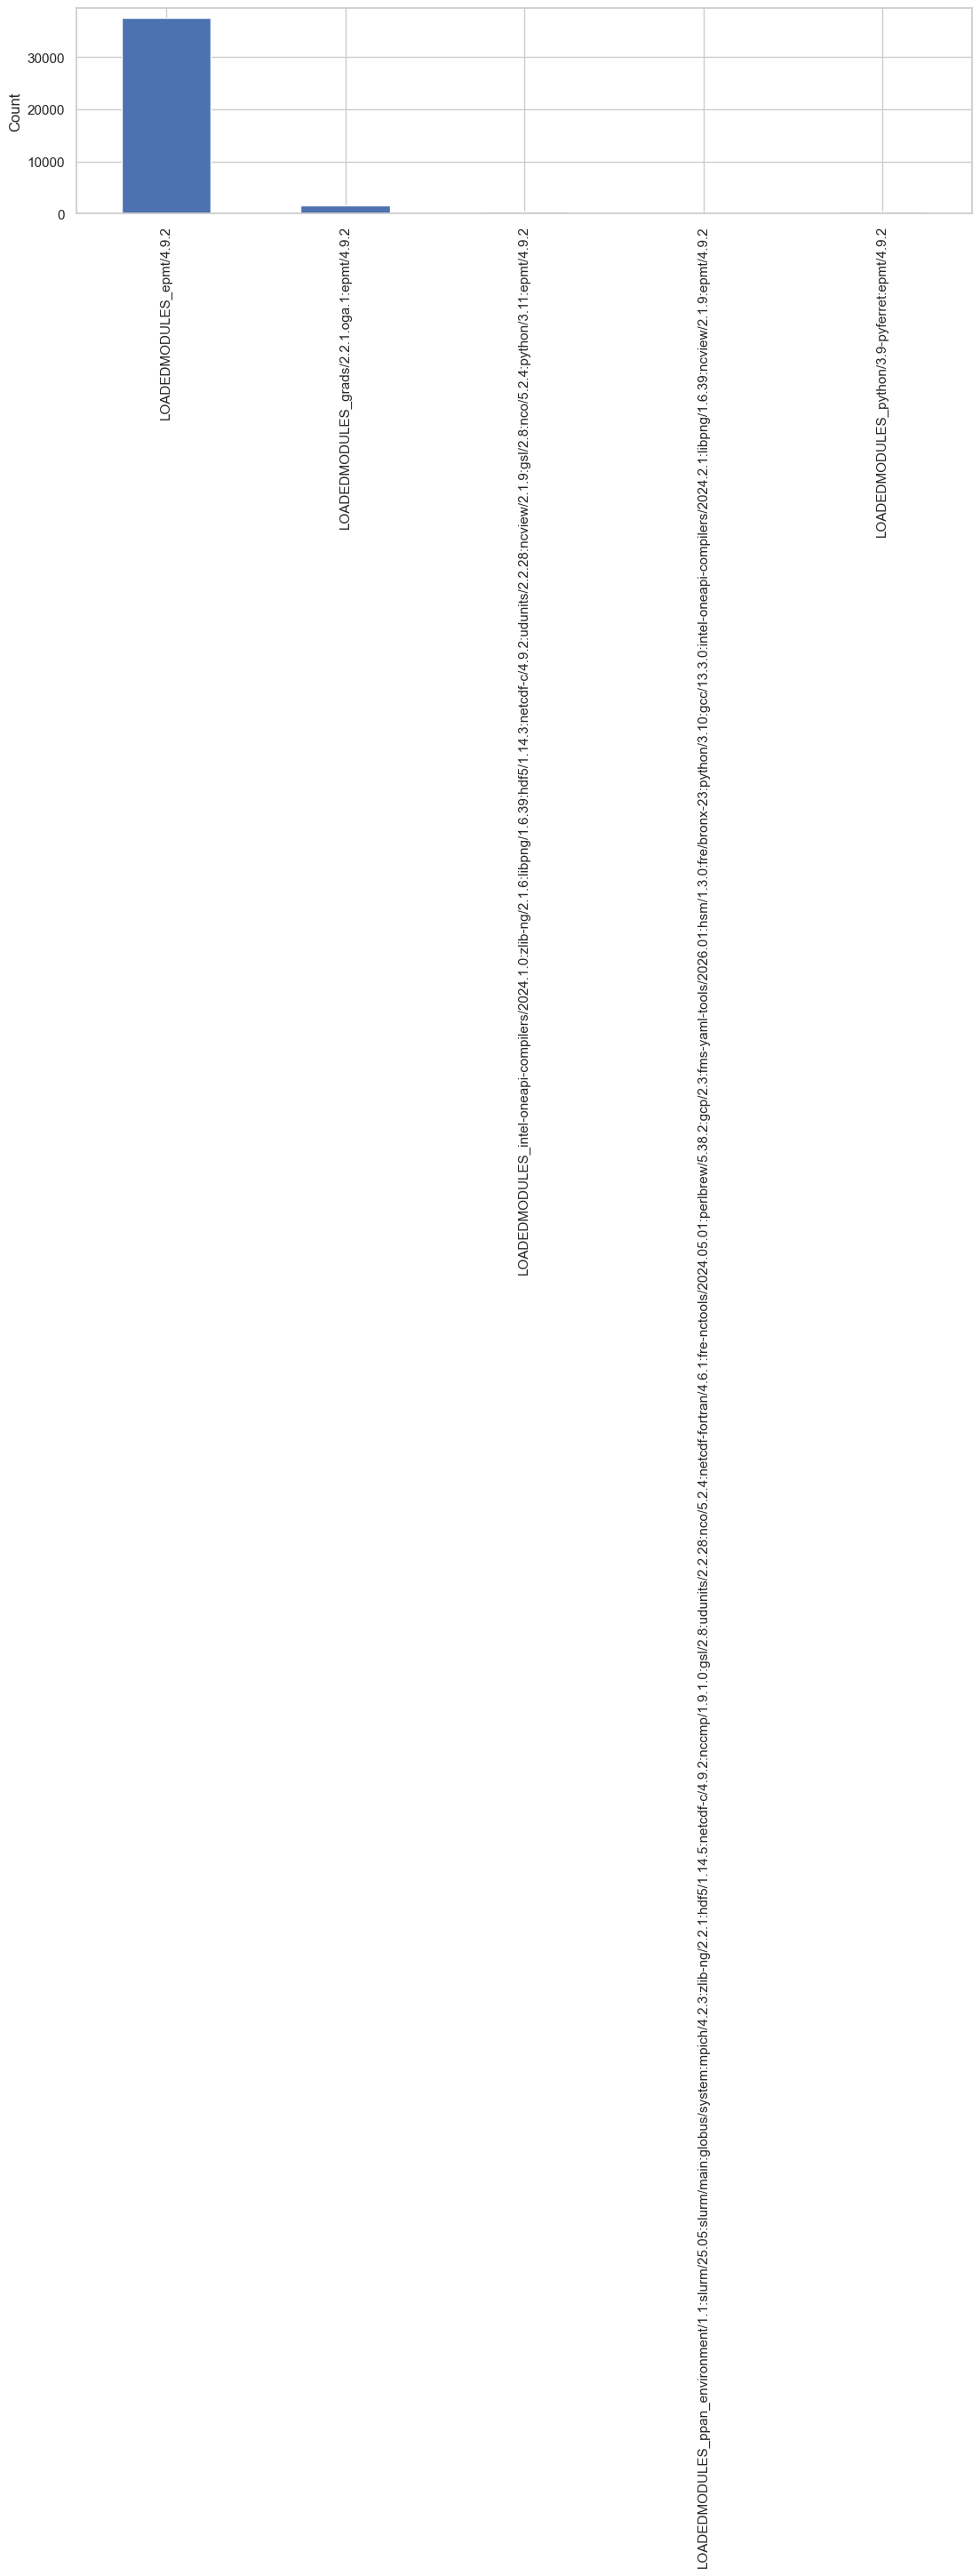

In [72]:
plot_one_category(df_categorical, "LOADEDMODULES")

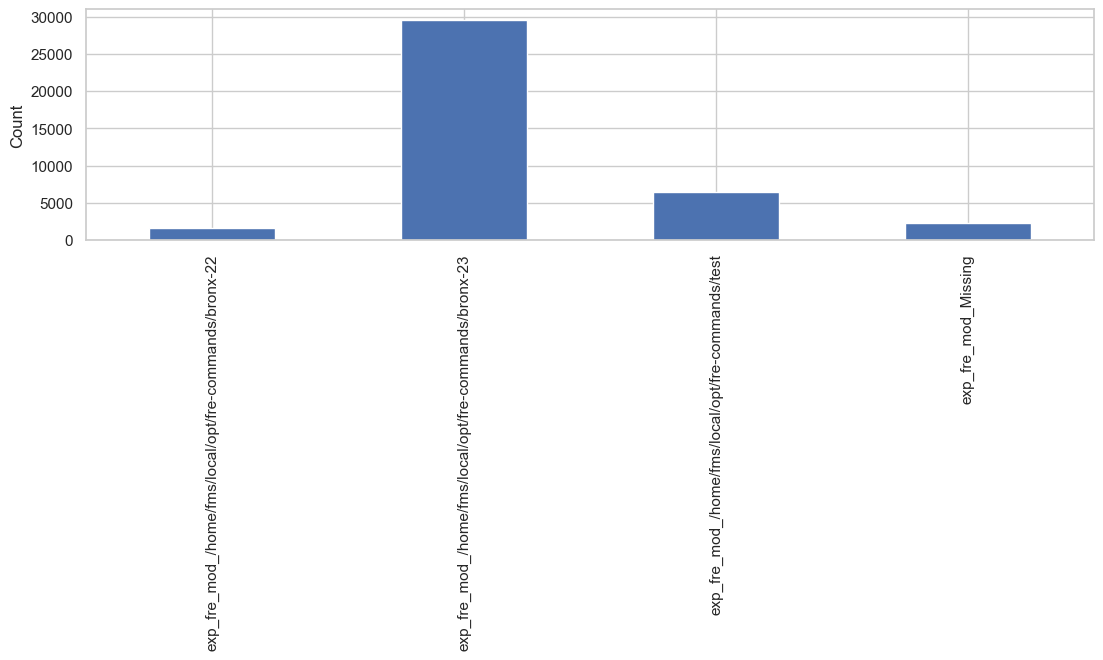

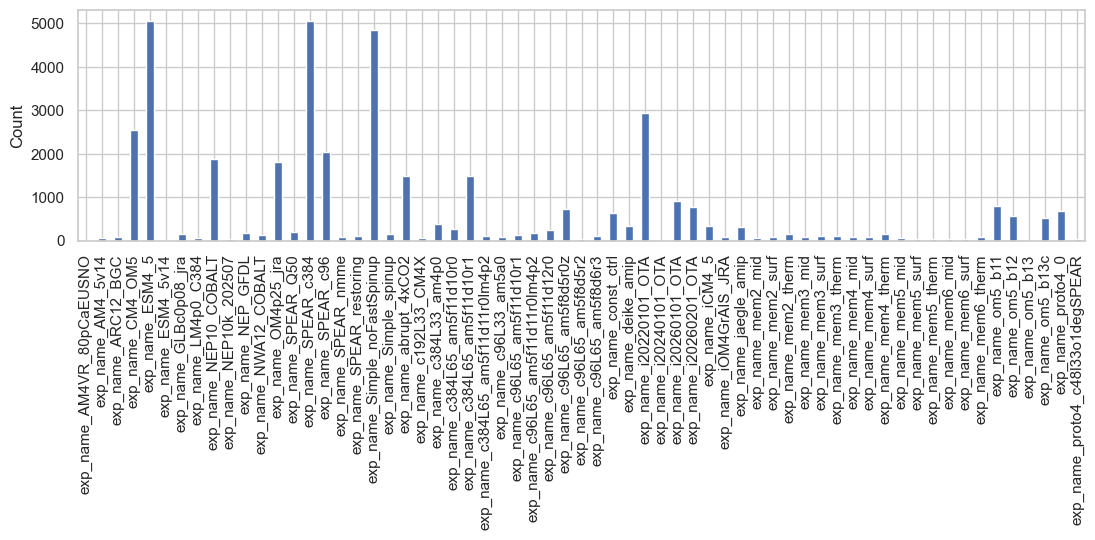

In [73]:
plot_one_category(df_categorical, "exp_fre_mod")
plot_one_category(df_categorical, "exp_name")

In [74]:
df_final = df_clean.copy()
df_final_categorical = df_categorical.copy()
df_final[df_final_categorical.columns] = df_final_categorical

/var/folders/9q/z65qt5dx1rx_677h_pkbsdx80000gn/T/ipykernel_3604/2131190090.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final[df_final_categorical.columns] = df_final_categorical


In [75]:
df_final.head()

,read_bytes,write_bytes,time_waiting,cpu_time,duration,minflt,majflt,SLURM_JOB_ACCOUNT,SLURM_NTASKS,SLURM_SCRIPT_CONTEXT,...,script_name_pjk_atmos,script_name_proto4_0,script_name_proto4_c48l33o1degSPEAR,script_name_sak_atmos,script_name_tk_atmos,script_name_van_ch4,script_name_van_mon,script_name_van_o3analysis,script_name_wheeler_kiladis,script_name_yim_aer
0,25.686867,25.196333,21.178675,19.315824,21.024541,16.595646,4.499810,gfdl_sd,1.0,prolog_task,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,26.997183,26.491772,21.198902,20.519708,21.712899,18.024777,4.564348,gfdl_sd,1.0,prolog_task,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,23.754981,23.460674,20.976034,18.079300,20.821709,15.533278,0.693147,gfdl_sd,1.0,prolog_task,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,14.739389,16.031551,20.782174,16.571821,20.468218,14.420871,2.302585,gfdl_sd,1.0,prolog_task,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,24.662084,24.407498,21.604099,19.514315,21.228419,16.135398,0.000000,gfdl_sd,1.0,prolog_task,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [76]:
df_final = df_final.drop(columns=['SLURM_JOB_ACCOUNT', 'SLURM_SCRIPT_CONTEXT', 'LOADEDMODULES', 'exp_component', 'exp_fre_mod', 'exp_name', 'exp_platform', 'exp_target', 'script_name'])
df_final.head()

,read_bytes,write_bytes,time_waiting,cpu_time,duration,minflt,majflt,SLURM_NTASKS,exp_time,exp_seg_months,...,script_name_pjk_atmos,script_name_proto4_0,script_name_proto4_c48l33o1degSPEAR,script_name_sak_atmos,script_name_tk_atmos,script_name_van_ch4,script_name_van_mon,script_name_van_o3analysis,script_name_wheeler_kiladis,script_name_yim_aer
0,25.686867,25.196333,21.178675,19.315824,21.024541,16.595646,4.499810,1.0,12.874164,12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,26.997183,26.491772,21.198902,20.519708,21.712899,18.024777,4.564348,1.0,12.874164,12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,23.754981,23.460674,20.976034,18.079300,20.821709,15.533278,0.693147,1.0,12.874164,12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,14.739389,16.031551,20.782174,16.571821,20.468218,14.420871,2.302585,1.0,12.874164,12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,24.662084,24.407498,21.604099,19.514315,21.228419,16.135398,0.000000,1.0,12.874164,12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [77]:
numeric_cols = df_final.select_dtypes(include="number").columns.tolist()
category_cols = df_final.select_dtypes(exclude="number").columns.tolist()

print("# numeric columns:", len(numeric_cols))
print("# category columns:", len(category_cols))

# numeric columns: 223
# category columns: 0


In [78]:
print(numeric_cols) # TODO: 223 is too many

['read_bytes', 'write_bytes', 'time_waiting', 'cpu_time', 'duration', 'minflt', 'majflt', 'SLURM_NTASKS', 'exp_time', 'exp_seg_months', 'SLURM_JOB_ACCOUNT_cefi', 'SLURM_JOB_ACCOUNT_gfdl_a', 'SLURM_JOB_ACCOUNT_gfdl_b', 'SLURM_JOB_ACCOUNT_gfdl_f', 'SLURM_JOB_ACCOUNT_gfdl_m', 'SLURM_JOB_ACCOUNT_gfdl_o', 'SLURM_JOB_ACCOUNT_gfdl_sd', 'SLURM_JOB_ACCOUNT_gfdl_w', 'SLURM_SCRIPT_CONTEXT_prolog_task', 'LOADEDMODULES_epmt/4.9.2', 'LOADEDMODULES_grads/2.2.1.oga.1:epmt/4.9.2', 'LOADEDMODULES_intel-oneapi-compilers/2024.1.0:zlib-ng/2.1.6:libpng/1.6.39:hdf5/1.14.3:netcdf-c/4.9.2:udunits/2.2.28:ncview/2.1.9:gsl/2.8:nco/5.2.4:python/3.11:epmt/4.9.2', 'LOADEDMODULES_ppan_environment/1.1:slurm/25.05:slurm/main:globus/system:mpich/4.2.3:zlib-ng/2.2.1:hdf5/1.14.5:netcdf-c/4.9.2:nccmp/1.9.1.0:gsl/2.8:udunits/2.2.28:nco/5.2.4:netcdf-fortran/4.6.1:fre-nctools/2024.05.01:perlbrew/5.38.2:gcp/2.3:fms-yaml-tools/2026.01:hsm/1.3.0:fre/bronx-23:python/3.10:gcc/13.3.0:intel-oneapi-compilers/2024.2.1:libpng/1.6.39:nc

In [79]:
date_str = datetime.today().strftime("%Y%m%d_%H%M%S")
date_str

'20260305_070749'

In [80]:
df_final.to_csv(f"epmt_data_cleaned_{date_str}.csv", index=False)

In [82]:
#df_final.to_parquet(f"epmt_data_cleaned_{date_str}.parquet")